## Data Exploration

The MAL data files are split into 5 types:

* `anime.csv` - data about anime themselves
* `anime_anime.csv` - anime recommendations (do users recommend animeB based on animeA)
* `user.csv` - user profile data
* `user_anime0000000000xx.csv` (10 zeros) - 70 shards of data containing all user ratings for all anime (up to data cutoff)
* `user_user.csv` - user friendship data

Of the data, the `user_anime0000000000xx.csv` shards will be most relevant because they contain all user rating data.

We'll start by getting an idea of the variables contained in each data file.

In [1]:
import pandas as pd

# Explore anime.csv
anime = pd.read_csv("../data/anime.csv", sep="\t")
print(anime.shape)
pd.set_option("display.max_columns", None)
print(anime.head(2))
print(anime.dtypes)
print(f"Unique anime statuses: {anime["status"].unique()}")
print(f"\"type\" values: {anime["type"].unique()}")
print(f"Number of NaN in anime[\"score\"]: {anime["score"].isna().sum()}")
print(f"Number of anime with no genre: {(anime["genres"].str.strip() == "").sum()}")
print(f"Number of anime with NaN episodes: {anime["num_episodes"].isna().sum()}")

(13379, 38)
   anime_id                                          anime_url  \
0      2366  https://myanimelist.net/anime/2366/Touma_Kishi...   
1      4940  https://myanimelist.net/anime/4940/Sabaku_no_K...   

                              title  \
0               Touma Kishinden Oni   
1  Sabaku no Kaizoku! Captain Kuppa   

                                            synopsis  \
0  Shuramaru is hated and feared by the villagers...   
1  Sometime in the future, the world was complete...   

                                            main_pic type source_type  \
0  https://cdn.myanimelist.net/images/anime/9/829...   TV        Game   
1  https://cdn.myanimelist.net/images/anime/9/736...   TV       Manga   

   num_episodes           status           start_date             end_date  \
0          25.0  Finished Airing  1995-10-05 00:00:00  1996-03-21 00:00:00   
1          26.0  Finished Airing  2001-08-13 00:00:00  2002-02-11 00:00:00   

        season    studios            genres  sc

In [3]:
# Explore anime_anime.csv
anime_anime = pd.read_csv("../data/anime_anime.csv", sep="\t")
print(anime_anime.shape)
print(anime_anime.head(4))
print(anime_anime.dtypes)
print(anime_anime[anime_anime['related'].notna()]['related'].value_counts().sort_index())
print(anime_anime[anime_anime['num_recommenders'].notna()]['num_recommenders'].value_counts().sort_index())

(214271, 7)
   animeA  animeB  recommendation recommendation_url  num_recommenders  \
0   20955   16371               0                NaN               NaN   
1   40761   10087               0                NaN               NaN   
2   31675   20583               0                NaN               NaN   
3   33455   40716               0                NaN               NaN   

   related relation_type  
0        1         Other  
1        1         Other  
2        1         Other  
3        1         Other  
animeA                  int64
animeB                  int64
recommendation          int64
recommendation_url        str
num_recommenders      float64
related                 int64
relation_type             str
dtype: object
related
0     85613
1    128658
Name: count, dtype: int64
num_recommenders
2.0      72718
3.0       4556
4.0       2432
5.0       1596
6.0       1044
         ...  
159.0        2
164.0        2
171.0        2
175.0        2
606.0        2
Name: count, Lengt

In [5]:
# Explore user.csv
user = pd.read_csv("../data/user.csv", sep="\t")
print(user.shape)
print(user.head(4))

(1123284, 11)
           user_id                                         user_url  \
0         kir1yama         https://myanimelist.net/profile/Kir1yama   
1         smatster         https://myanimelist.net/profile/smatster   
2        suzuhrevv        https://myanimelist.net/profile/SuzuhRevv   
3  pheseantnetsuke  https://myanimelist.net/profile/PheseantNetsuke   

      last_online_date  num_watching  num_completed  num_on_hold  num_dropped  \
0  2021-08-27 15:46:00            28            606           48           48   
1  2022-02-25 11:13:03            46           1188          209           31   
2  2022-02-21 20:02:48            47            517          180           52   
3  2022-02-21 16:29:01            53            368           57           44   

   num_plan_to_watch  num_days  mean_score                      clubs  
0                113     228.4        6.69                        NaN  
1               2759     212.1        8.38  29299|70446|379|36473|907  
2       

In [6]:
# Explore user_anime[...].csv shard
ratings = pd.read_csv("../data/user_anime000000000000.csv", sep="\t")
print(ratings.shape)
print(ratings.head(5))
print(ratings['score'].value_counts(dropna=False).head(10))
print(ratings['status'].value_counts(dropna=False))

(4003081, 16)
   user_id  anime_id  favorite  review_id review_date  review_num_useful  \
0  -------         1         0        NaN         NaN                NaN   
1  -------      1000         0        NaN         NaN                NaN   
2  -------      1002         0        NaN         NaN                NaN   
3  -------      1003         0        NaN         NaN                NaN   
4  -------      1004         0        NaN         NaN                NaN   

   review_score  review_story_score  review_animation_score  \
0           NaN                 NaN                     NaN   
1           NaN                 NaN                     NaN   
2           NaN                 NaN                     NaN   
3           NaN                 NaN                     NaN   
4           NaN                 NaN                     NaN   

   review_sound_score  review_character_score  review_enjoyment_score  score  \
0                 NaN                     NaN                     NaN 

In [7]:
# Explore user_user.csv
user_user = pd.read_csv("../data/user_user.csv", sep="\t")
print(user_user.shape)
print(user_user.head(4))

(5048994, 4)
           userA         userB  friends      friendship_date
0     guirumeuto        vitoon        1  2020-01-27 07:21:00
1  sleepwalkerbr  taric_uchiha        1  2020-07-01 15:38:00
2      ginta-san    kellymoons        1  2013-06-17 03:41:00
3      abbi11485   littlejaxit        1  2018-08-05 06:06:00


---

Now that we know what's in each file we can go deeper into the useful data

In [8]:
print(ratings['user_id'].value_counts().head(10))
print(f"\nRows with score: {ratings['score'].notna().sum()}")
print(f"\nRows without score: {ratings['score'].isna().sum()}")

user_id
__admin__          10661
-matthew-           5899
-sabre-             5120
-hnk                5040
-koku               4933
_cjessop19_         4791
-_edg3l0rdo24_-     4203
0unknown0           3913
_shira              3691
_kuuma              3409
Name: count, dtype: int64

Rows with score: 2283451

Rows without score: 1719630


In [9]:
print(ratings[ratings['score'].notna()]['score'].value_counts().sort_index())
print(f"\nUnique users in this shard: {ratings[ratings['score'].notna()]['user_id'].nunique()}")

score
1.0      19005
2.0      20068
3.0      34691
4.0      69690
5.0     147819
6.0     275831
7.0     517480
8.0     560486
9.0     364522
10.0    273859
Name: count, dtype: int64

Unique users in this shard: 17352


Score rating will be our main metric for tuning the CF part of the model. Users and anime with few ratings will impact CF negatively, so we'll get a better idea of the distribution of ratings per user and ratings per anime.

In [10]:
user_rating_counts = ratings[ratings['score'].notna()]['user_id'].value_counts()
print(f"\nNumber of rated anime per user: {user_rating_counts}")
print(f"\nMean number of ratings: {user_rating_counts.mean()}")
print(f"\nMedian number of ratings: {user_rating_counts.median()}")

anime_rating_counts = ratings[ratings['score'].notna()]['anime_id'].value_counts()
print(f"\nNumber of ratings per anime: {anime_rating_counts}")
print(f"\nMean number of ratings per anime: {anime_rating_counts.mean()}")
print(f"\nMedian number of ratings per anime: {anime_rating_counts.median()}")


Number of rated anime per user: user_id
-hnk               4720
-koku              4605
-_edg3l0rdo24_-    4024
-sabre-            3877
_shira             3647
                   ... 
_tise                 1
_tux_                 1
_ubermensch_          1
_uwu_senpai           1
_uzuki_               1
Name: count, Length: 17352, dtype: int64

Mean number of ratings: 131.59583909635776

Median number of ratings: 77.0

Number of ratings per anime: anime_id
16498    10063
1535      9458
30276     8258
31964     8256
32281     8139
         ...  
5561         1
5565         1
6397         1
41210        1
3315         1
Name: count, Length: 11700, dtype: int64

Mean number of ratings per anime: 195.16675213675214

Median number of ratings per anime: 20.0


In order to determine what rating data we'll be keeping, I'll visualize the distributions of user and anime ratings. Cutoff points for what data to keep will be determined from the graphs.

Text(0, 0.5, '# of users with x many ratings')

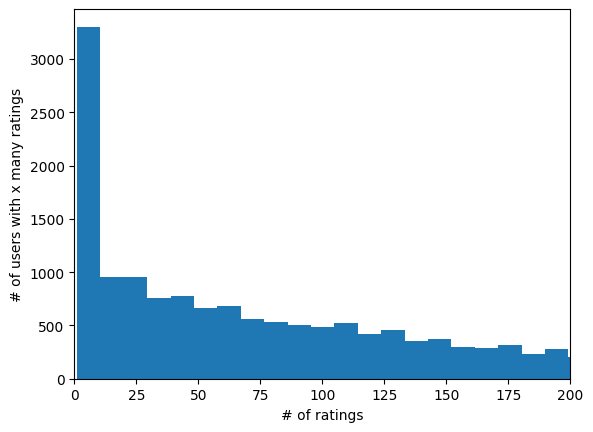

In [11]:
import matplotlib.pyplot as plt

# Get anime ratings distribution
plt.hist(user_rating_counts, bins=500)
plt.xlim(0, 200)
plt.xlabel("# of ratings")
plt.ylabel("# of users with x many ratings")

Text(0, 0.5, '# of anime with x many ratings')

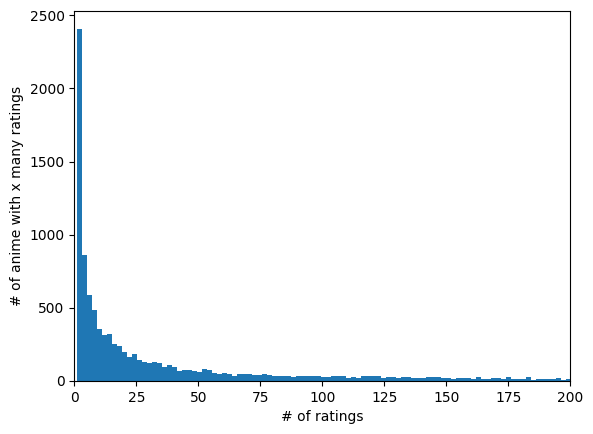

In [12]:
# Get anime ratings distribution
plt.hist(anime_rating_counts, bins=5000)
plt.xlim(0, 200)
plt.xlabel("# of ratings")
plt.ylabel("# of anime with x many ratings")

We can see that there are many users with few ratings and many anime with few ratings. Users and anime with too few ratings will throw off collaborative filtering (CF) performance, so I will define a rating cutoff for what data to keep.

For `user_rating_counts`, the average number of ratings per user is 131, with the median at 77. This indicates a more even distribution, evidenced by the histogram, but low numbers will still throw off model performance. The distribution of user ratings shows that a cutoff point of 25 ratings does not include many more users than a cutoff of 50, as the large majority of users have fewer than 10 ratings. I believe a cutoff of 50 ratings would skew the model's predictions towards the preferences of more serious anime watchers (those who have seen over 50 anime), so users with fewer than 25 ratings will be removed. This cutoff gives a nice balance between including data and accommodating various watcher types.

For `anime_rating_counts`, the average number of anime ratings is ~195, yet the median is 20 ratings. This indicates there are many anime with less than 20 ratings. The histogram shows that there is a disproportionately high number of anime with 50 or fewer ratings. These entries would skew the results and introduce bias, so anime with fewer than 50 user ratings will be removed from the data.

---

In [14]:
print(ratings['status'].unique())

<StringArray>
['completed', 'plan_to_watch', 'on_hold', 'watching', 'dropped']
Length: 5, dtype: str


An entry in a user's anime list has a completion status, contained in `user_anime[...].csv['status']`. Status can take on values of [`completed`, `plan_to_watch`, `on_hold`, `watching`, `dropped`]. For the purposes of this model, the only two relevant statuses are `completed` and `dropped`; entries with statuses of the other 3 values will be dropped.

The bulk of the final data will be `completed` shows, because we don't want to consider ratings from users who don't know what the whole show is like. However, a user signaling that they `dropped` a show can also be useful data. If a user watches only one or two episodes and drops, that doesn't provide much information. But if a user sits through a certain amount of the show and still decides to drop, that is a strong negative signal.

Text(0, 0.5, '# of drops')

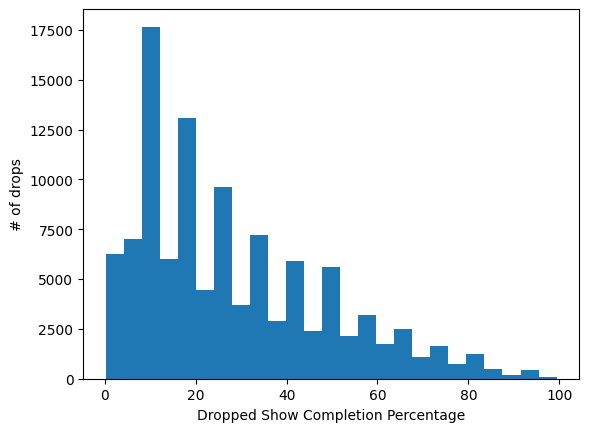

In [24]:
dropped = ratings[ratings['status'] == 'dropped'].copy()
dropped = dropped.merge(anime[['anime_id', 'num_episodes']], on='anime_id', how='left')
dropped['completion_pct'] = dropped['progress'] / dropped['num_episodes']

plt.hist(dropped['completion_pct'] * 100, bins=25)
plt.xlabel("Dropped Show Completion Percentage")
plt.ylabel("# of drops")

The distribution of completion percentage for dropped ratings indicates that the majority of drops happen early in a show, with a notable drop-off after the half way point. Given this information, I believe 50% completion progress is a good cutoff for the included data to reflect meaningful user opinions.

## Key Takeaways

From the data files, the `user_anime0000000000xx.csv` shards will be most of the data we use. Specifically, the `user_id`, `anime_id`, and `score` columns. These columns will be most relevant for CF to find a pattern from raw score data.

The model's second step will be content-based filtering. Additional variables from the data such as anime.csv's `source_type`, anime_anime.csv's `num_recommenders`, and user_anime.csv's `favorite` may be useful for fine-tuning the model's recommendations.

For `user_anime.csv['status']`, only entries with a value of `completed` will be included in the data -- with one exception. Entries with a value of `dropped` where completion `progress` is more than 50% will also be included.

There is also the possibility of analyzing user reviews from `user_anime[...].csv` shards via LLM or sentiment analysis to get a more nuanced understanding of a show and improve recommendations. If this approach is feasible it will be explored in the later parts of the project.